In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
from sklearn.calibration import calibration_curve

In [101]:
all_tcn = np.load("../outputs/all_tcn.npy")
all_xgb = np.load("../outputs/all_xgb.npy")
all_y = np.load("../outputs/all_y.npy")

# Final ensemble (same as notebook 8)
ensemble_preds = 0.6 * all_xgb + 0.4 * all_tcn

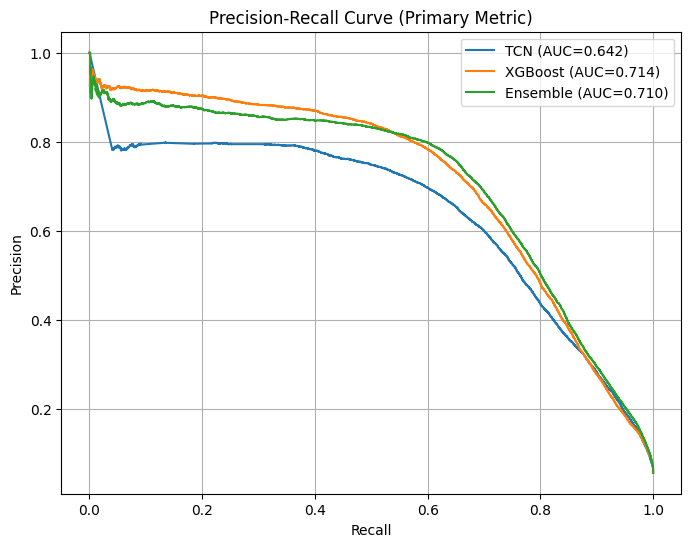

In [102]:
def plot_pr(y_true, preds, label):
    precision, recall, _ = precision_recall_curve(y_true, preds)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label} (AUC={pr_auc:.3f})")


plt.figure(figsize=(8,6))

plot_pr(all_y, all_tcn, "TCN")
plot_pr(all_y, all_xgb, "XGBoost")
plot_pr(all_y, ensemble_preds, "Ensemble")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Primary Metric)")
plt.legend()
plt.grid()

plt.savefig("../outputs/pr_curve.png")
plt.show()

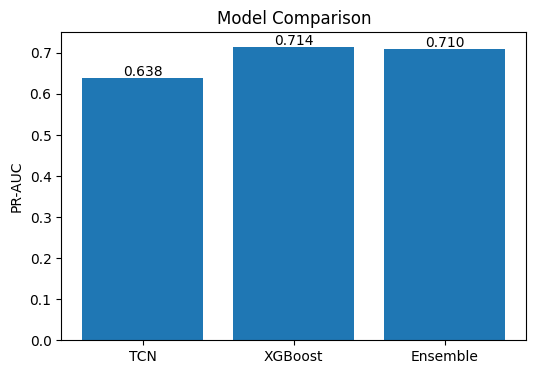

In [103]:
scores = {
    "TCN": average_precision_score(all_y, all_tcn),
    "XGBoost": average_precision_score(all_y, all_xgb),
    "Ensemble": average_precision_score(all_y, ensemble_preds)
}

plt.figure(figsize=(6,4))
plt.bar(scores.keys(), scores.values())

plt.ylabel("PR-AUC")
plt.title("Model Comparison")

for i, v in enumerate(scores.values()):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.savefig("../outputs/model_comparison.png")
plt.show()

In [104]:
threshold = 0.24  # 🔥 FINAL CHOICE

final_preds = (ensemble_preds >= threshold).astype(int)

In [105]:
precision = precision_score(all_y, final_preds)
recall = recall_score(all_y, final_preds)
f1 = f1_score(all_y, final_preds)
pr_auc = average_precision_score(all_y, ensemble_preds)

print("Final Metrics:")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Final Metrics:
PR-AUC: 0.710
Precision: 0.310
Recall: 0.892
F1 Score: 0.460


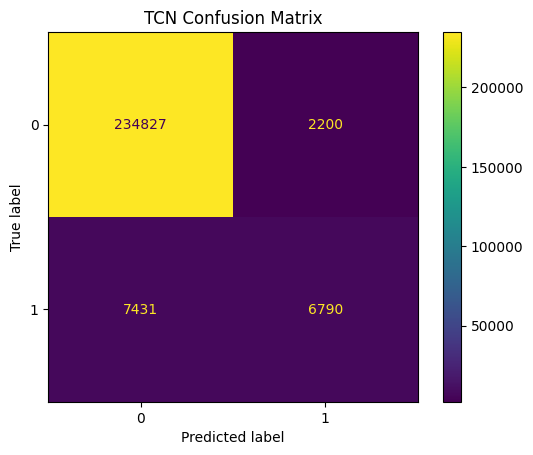

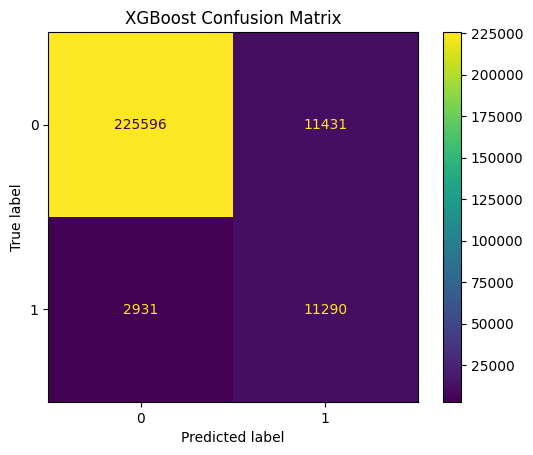

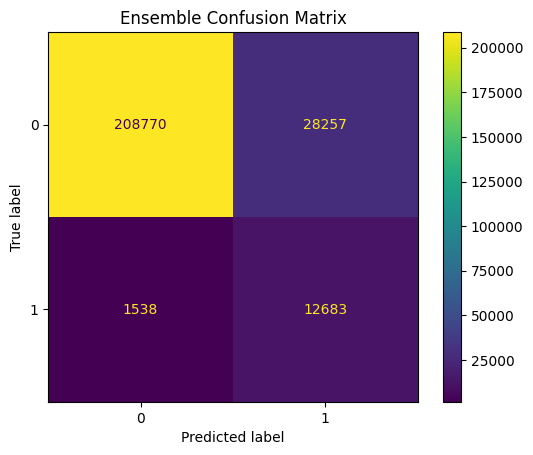

In [106]:
def plot_cm(y_true, preds, name):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    
    plt.title(f"{name} Confusion Matrix")
    plt.savefig(f"../outputs/{name}_cm.png")
    plt.show()


# Individual models (threshold = 0.5)
plot_cm(all_y, (all_tcn >= 0.5).astype(int), "TCN")
plot_cm(all_y, (all_xgb >= 0.5).astype(int), "XGBoost")

# Final ensemble
plot_cm(all_y, final_preds, "Ensemble")

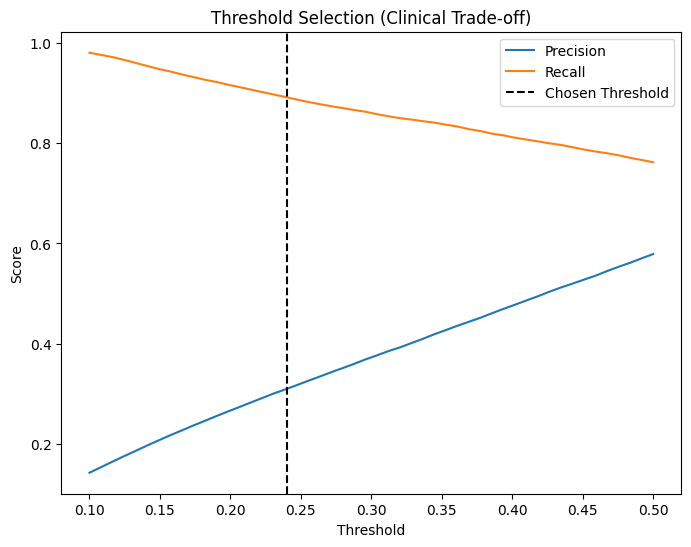

In [107]:
thresholds = np.linspace(0.1, 0.5, 50)

precisions = []
recalls = []

for t in thresholds:
    preds = (ensemble_preds >= t).astype(int)
    
    precisions.append(precision_score(all_y, preds))
    recalls.append(recall_score(all_y, preds))


plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")

plt.axvline(0.24, linestyle="--", color="black", label="Chosen Threshold")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Selection (Clinical Trade-off)")
plt.legend()

plt.savefig("../outputs/threshold_tradeoff.png")
plt.show()

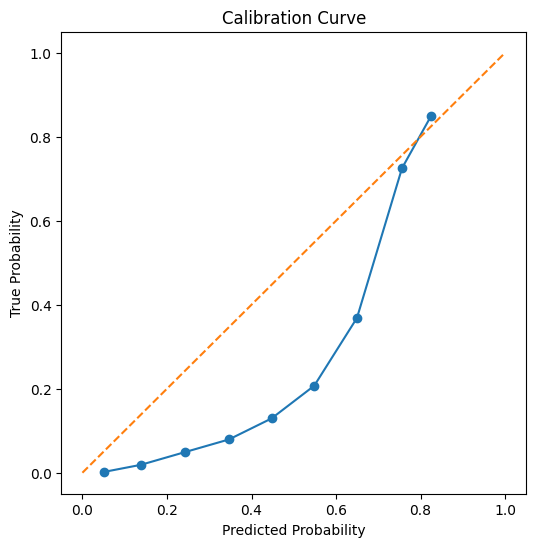

In [108]:
prob_true, prob_pred = calibration_curve(all_y, ensemble_preds, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")

plt.savefig("../outputs/calibration.png")
plt.show()

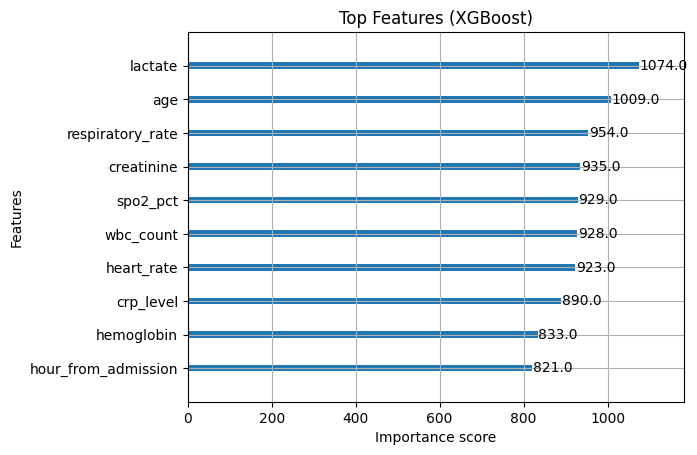

In [109]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.load_model("../models/xgboost/xgb_fold_0.json")

xgb.plot_importance(model, max_num_features=10)
plt.title("Top Features (XGBoost)")
plt.savefig("../outputs/feature_importance.png")
plt.show()

In [110]:
summary = pd.DataFrame({
    "Metric": ["PR-AUC", "Precision", "Recall", "F1"],
    "Value": [pr_auc, precision, recall, f1]
})

print(summary)
summary.to_csv("../outputs/final_metrics.csv", index=False)

      Metric     Value
0     PR-AUC  0.709797
1  Precision  0.309795
2     Recall  0.891850
3         F1  0.459854
